# TN2211 Session 8: Transistors

## Instruments


In [280]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt
import math
import numpy as np
import time
from scipy.optimize import curve_fit

In [37]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR')

In [38]:
scope = Scope("SDS")
gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR
Setting memory depth to 10k points
Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR


# Transistor IV Cuves


Configure scope and generator with a reasonable set of defaults:

In [410]:
# Helper functions

def add_zero_lines(): # to save matplotlib typing...
    plt.axhline(0,ls=":",c='grey')
    plt.axvline(0,ls=":",c='grey')

def bin_average(x,N=10): # with this we can "squeeze out" a bit more signal to noise ratio
    n_out = len(x)//N
    x = np.reshape(x[:N*n_out], (n_out, N))
    return np.average(x, axis=1)

def set_gate_voltage(V):
    gen.write("C2:BSWV OFST,%e" % V)

def set_Vdd_range(v1,v2):
    offset = v1+v2/2
    amp = v2-v1
    gen.write("C1:BSWV AMP,%e,OFST,%e" % (amp,offset))

def get_IV(R=100):
    # Best to stop the acquisition so we get two traces run in the same trace
    # If triggering is set up well and highly accurate, should not matter...but
    # good in any case to do. It also seems to speed up data transfer? 
    scope.write("TRIG:STOP")
    t,v1 = np.array(scope.get_trace(1, save_file = False)) # voltage above readout resistor
    t,v2 = np.array(scope.get_trace(2, save_file = False)) # voltage at drain of transistor
    scope.write("TRIG:RUN")
    v1 = np.array(v1)
    v2 = np.array(v2)
    i = (v1-v2)/R
    # It's convenient to sort them by drain voltage (x-axis of future plots)
    ind = np.argsort(v2)
    v2 = v2[ind]
    i = i[ind]
    return i,v2

In [411]:
# Configure the channels we will use
scope.write("CHAN1:SWIT ON")
scope.write("CHAN2:SWIT ON")
scope.write("CHAN1:COUP DC")
scope.write("CHAN2:COUP DC")
scope.write("CHAN3:SWIT OFF")
scope.write("CHAN1:SCAL 2")
scope.write("CHAN2:SCAL 2")
scope.write("CHAN1:OFFS -5")
scope.write("CHAN2:OFFS -5")
scope.write("CHAN1:VIS ON")
scope.write("CHAN2:VIS ON")

scope.write("CHAN1:BWL 20M") # we will be fighting noise and don't need 20 MHz
scope.write("CHAN2:BWL 20M") # we will be fighting noise and don't need 20 MHz

# We will use Ch4 of the scope connected to the sync out of the 
# generator for triggering
scope.write("CHAN4:SWIT ON")
scope.write("CHAN4:SCAL 2")
scope.write("TRIG:EDGE:SOUR C4")
scope.write("TRIG:EDGE:LEV 1")
scope.write("CHAN4:VIS OFF")

# Set up the Vdd sweep and the gate voltage
# We will sweep Vdd from 0 to 10V
# Ch1 goes to the drain
# Ch2 goes to the source
gen.write("C1:BSWV WVTP,RAMP,FRQ,1e3,AMP,10,OFST,5")
gen.write("C2:BSWV WVTP,DC,OFST,4")
gen.write("C1:OUTP ON")
gen.write("C2:OUTP ON")
scope.write("TIM:SCAL .2e-3")
time.sleep(1)
gen.write("C1:SYNC ON,TYPE,CH1")

# We will set up a function to display C1-C2, the voltage across the resistor
# which will be proportial to the current

scope.write("FUNC1 ON")
scope.write("FUNC1:OPER SUBT")
scope.write("FUNC1:SOUR1 C1")
scope.write("FUNC1:SOUR2 C2")
scope.write("FUNC1:SCAL 2")
scope.write("FUNC1:POS -5")

scope.write("TRIG:RUN")

If you have connected things correctly, the above code should now show three traces on your oscilloscope display showing the voltage above the readout resistor, the voltage on the drain, and a math function that calculates the difference between the two, proportional to the current. The math trace should show you a clear saturation already, which you can adjust with the the gate voltage. 

Take a screenshot for your logbook, and then play around with the gate voltage, adding screenshots. Pick two screenshots for your summary and analysis report. 

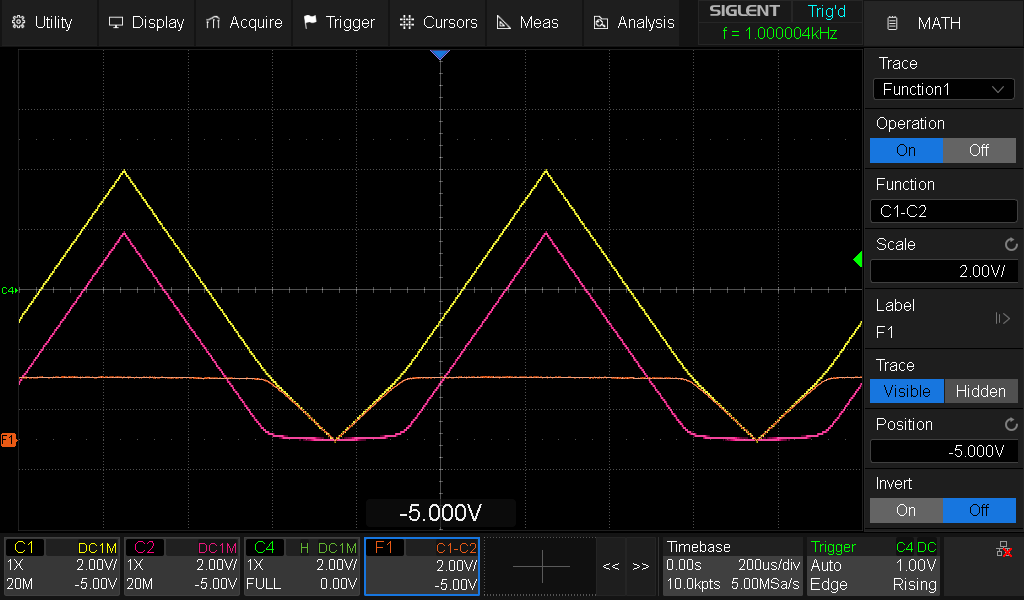

In [412]:
# For your logbook:
scope.get_screenshot()

In [413]:
# Play with the value and see what it does 
# Try to find the threshold voltage at which the FET is no longer conducting
set_gate_voltage(4.1)  

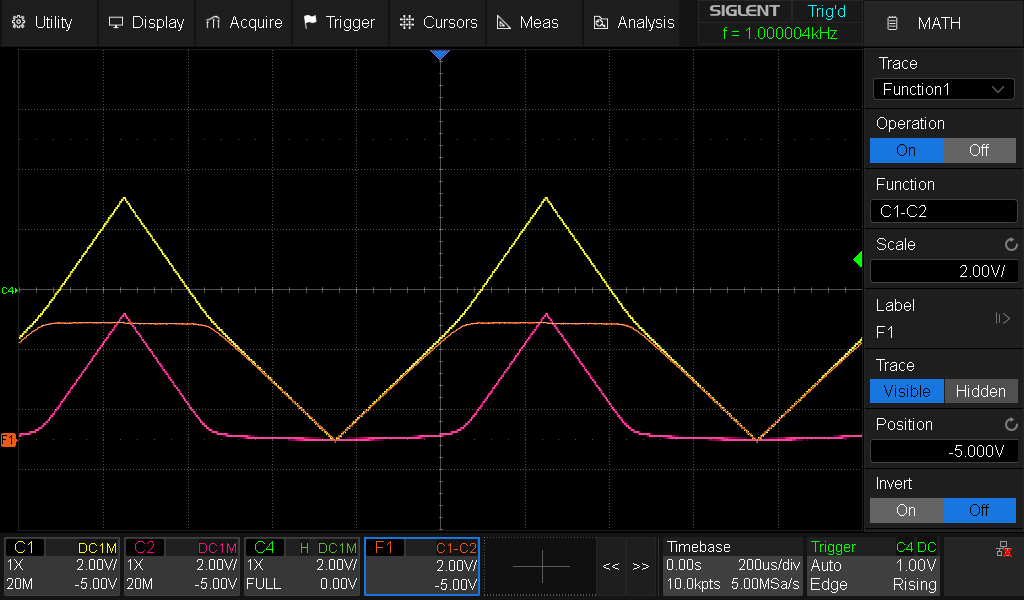

In [414]:
scope.get_screenshot()

We can use the helper functions to download the traces and convert the data into a current-voltage measurement of the FET. We will start with a gate voltage of 4V:

In [415]:
Vg = 4.0
set_gate_voltage(Vg) 
i,v = get_IV()

You can use this code cell to plot the data. You should adjust the variable `R_sd` to try your best to estimate what the channel resistance is in the linear regime for a gate voltage of 4V:

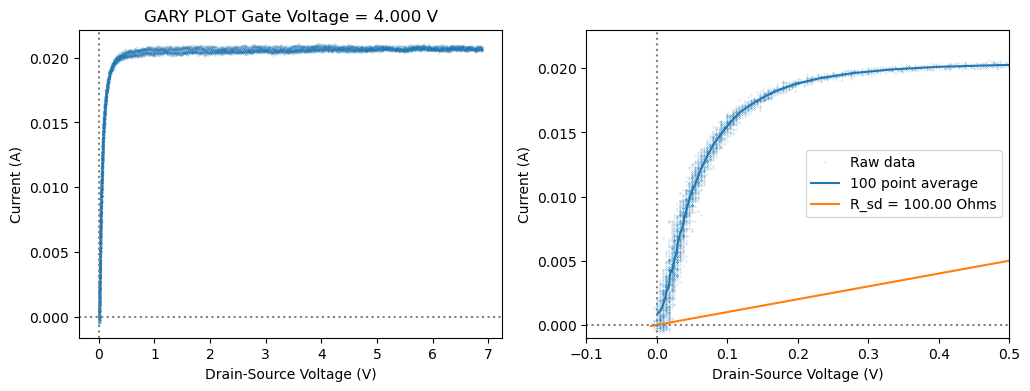

In [416]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(v,i, ".", ms=0.2)
plt.xlabel("Drain-Source Voltage (V)")
plt.ylabel("Current (A)")
add_zero_lines()
plt.title("GARY PLOT Gate Voltage = %.3f V" % Vg) # remove Gary's name :)

# Try out different resistor values to estimate
# the channel resistance from your data
R_sd = 100 # 100 ohms is definintely the wrong value :)
plt.subplot(122)
l, = plt.plot(v,i, ".", ms=0.2, label="Raw data")
# Useful to average the data a bit to get better SNR and get 
# rid of DAC quantisation levels. We have lots of points so
# no worry about losing points :)
Navg = 100
plt.plot(bin_average(v,Navg),bin_average(i,Navg),c = l.get_color(), label="%d point average" % Navg)
plt.xlabel("Drain-Source Voltage (V)")
plt.ylabel("Current (A)")
plt.xlim(-0.1,0.5)
plt.ylim(-1e-3,23e-3)
plt.plot(v,v/R_sd, label="R_sd = %.2f Ohms" % R_sd)
plt.legend()
add_zero_lines()

We can use this code to take a bunch of IVs for different gate voltages:

In [176]:
Vg_values = np.arange(3.8,4.15,0.05)
i_traces = []
v_traces = []

for vg in Vg_values:
    set_gate_voltage(vg)
    time.sleep(0.5)
    i,v = get_IV()
    i_traces.append(i)
    v_traces.append(v)

Saved to file scope_trace_2026-02-06-12.54.45.dat
Saved to file scope_trace_2026-02-06-12.54.45.dat
Saved to file scope_trace_2026-02-06-12.54.45.dat
Saved to file scope_trace_2026-02-06-12.54.46.dat
Saved to file scope_trace_2026-02-06-12.54.46.dat
Saved to file scope_trace_2026-02-06-12.54.47.dat
Saved to file scope_trace_2026-02-06-12.54.47.dat
Saved to file scope_trace_2026-02-06-12.54.47.dat
Saved to file scope_trace_2026-02-06-12.54.48.dat
Saved to file scope_trace_2026-02-06-12.54.48.dat
Saved to file scope_trace_2026-02-06-12.54.49.dat
Saved to file scope_trace_2026-02-06-12.54.49.dat
Saved to file scope_trace_2026-02-06-12.54.50.dat
Saved to file scope_trace_2026-02-06-12.54.50.dat
Saved to file scope_trace_2026-02-06-12.54.51.dat
Saved to file scope_trace_2026-02-06-12.54.51.dat


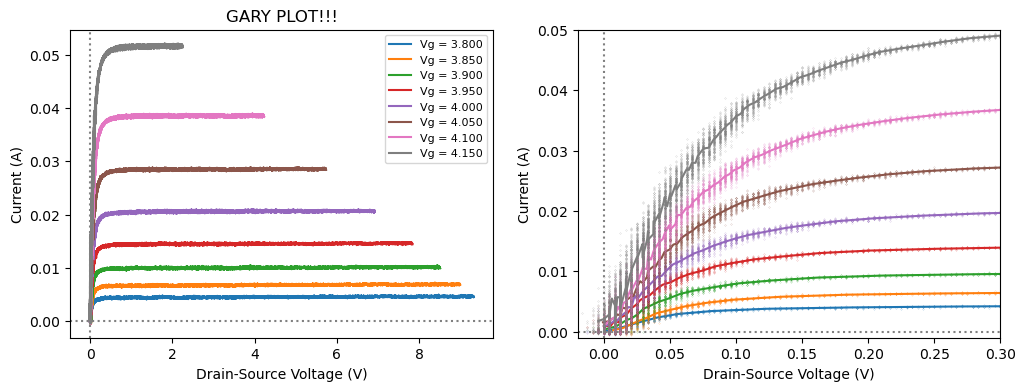

In [213]:
plt.figure(figsize=(12,4))
plt.subplot(121)
for n in range(len(Vg_values)):
    plt.plot(v_traces[n], i_traces[n], label="Vg = %.3f" % Vg_values[n])
plt.legend(prop={'size': 8})
plt.xlabel("Drain-Source Voltage (V)")
plt.ylabel("Current (A)")
plt.title("GARY PLOT!!!") # comment this out or give it a name of your choice :)
add_zero_lines()

plt.subplot(122)
for n in range(len(Vg_values)):
    l, = plt.plot(v_traces[n], i_traces[n], '.', ms=0.2, label="Vg = %.3f" % Vg_values[n])
    plt.plot(bin_average(v_traces[n],100),bin_average(i_traces[n],100),c = l.get_color())
plt.xlabel("Drain-Source Voltage (V)")
plt.ylabel("Current (A)")
plt.xlim(-0.02,0.3)
plt.ylim(-1e-3,50e-3)
add_zero_lines()

# Linear response regime: Threshold voltage and depletion

In [400]:
# Configure the channels we will use
scope.write("CHAN1:SWIT ON")
scope.write("CHAN2:SWIT ON")
scope.write("CHAN1:COUP DC")
scope.write("CHAN2:COUP DC")
scope.write("CHAN3:SWIT OFF")
scope.write("CHAN1:OFFS 0")
scope.write("CHAN2:OFFS 0")
scope.write("CHAN1:VIS ON")
scope.write("CHAN2:VIS ON")
scope.write("CHAN1:SCAL 10e-3")
scope.write("CHAN2:SCAL 10e-3")
scope.write("CHAN1:BWL 20M") # we will be fighting noise and don't need 20 MHz
scope.write("CHAN2:BWL 20M") # we will be fighting noise and don't need 20 MHz

# We will use Ch4 of the scope connected to the sync out of the 
# generator for triggering
scope.write("CHAN4:SWIT ON")
scope.write("CHAN4:SCAL 2")
scope.write("TRIG:EDGE:SOUR C4")
scope.write("TRIG:EDGE:LEV 1")
scope.write("CHAN4:VIS OFF")

# Set up the Vdd sweep and the gate voltage
# We will sweep Vdd from 0 to 10V
# Ch1 goes to the drain
# Ch2 goes to the source
gen.write("C1:BSWV WVTP,SINE,FRQ,1e3,AMP,0.05,OFST,0")
gen.write("C2:BSWV WVTP,DC,OFST,4")
gen.write("C1:OUTP ON")
gen.write("C2:OUTP ON")
scope.write("TIM:SCAL .5e-3")
time.sleep(1)
gen.write("C1:SYNC ON,TYPE,CH1")

scope.write("FUNC1 OFF")
scope.write("TRIG:RUN")

Let's take some traces:

In [381]:
scope.write("TRIG:STOP")
t,v1 = scope.get_trace(1)
t,v2 = scope.get_trace(2)
scope.write("TRIG:RUN")

Saved to file scope_trace_2026-02-06-15.44.35.dat
Saved to file scope_trace_2026-02-06-15.44.35.dat


As you will see, the traces are pretty noisy. But they do have lots of points. To use all of the information in the trace to get the best estimate we can of the sinusiodal amplitude, a good approach is to fit it with sine wave. This will give us much less noise on our estimation of the signal amplitude than if we did something like calculate the RMS amplitude like we did in the diode lab. 

You can see it in action here:

In [388]:
set_gate_voltage(4.0)

Text(0.5, 0, 'Time (s)')

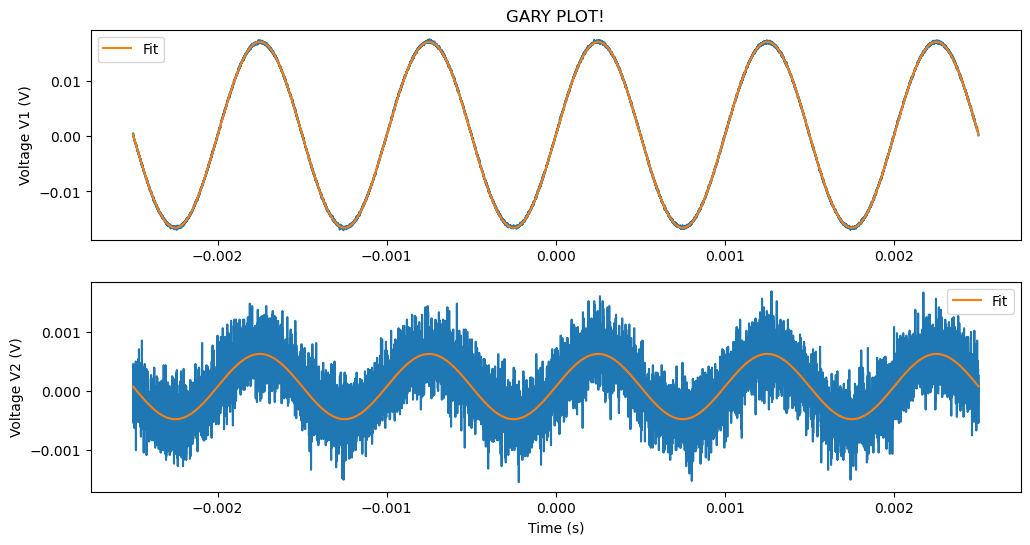

In [389]:
def f(t,a,b,c):
    return a*np.cos(2*np.pi*1e3*t+b)+c

def get_fit(t,v):
    (a,b,c), cov = curve_fit(f,t,v)
    return a,b,c

def get_amplitude(t,v):
    return get_fit(t,v)[0]

plt.figure(figsize=(12,6))
plt.subplot(211)
plt.title("GARY PLOT!") # remove or change :)
plt.plot(t,v1)
plt.ylabel("Voltage V1 (V)")
plt.plot(t,f(t,*get_fit(t,v1)), label="Fit")
plt.legend()
plt.subplot(212)
plt.plot(t,v2)
plt.ylabel("Voltage V2 (V)")
plt.plot(t,f(t,*get_fit(t,v2)), label="Fit")
plt.legend()
plt.xlabel("Time (s)")



You can repeat the above with differnt gate voltages to see what the signals look like in different regimes. 

We can also really easily automate this in python to step through different gate voltages and measure the two signal amplitudes for each gate voltage:

In [ ]:
Vg_values = np.arange(1,5,0.05)
v1_amp = []
v2_amp = []

for vg in Vg_values:
    set_gate_voltage(vg)
    time.sleep(0.1)
    scope.write("TRIG:STOP")
    t,v1 = scope.get_trace(1, save_file=False)
    t,v2 = scope.get_trace(2, save_file=False)
    scope.write("TRIG:RUN")
    v1_amp.append(get_amplitude(t,v1))
    v2_amp.append(get_amplitude(t,v2))

v1_amp = np.array(v1_amp)
v2_amp = np.array(v2_amp)

With the two optimal estimates of the small signal amplitude at each gate voltage, we can now calculate the current, the drain voltage, and the channel conductance to compare to our model from class:

Text(0.5, 1.0, 'GARY  Vt = 1.500  dG/dVg = 100.0')

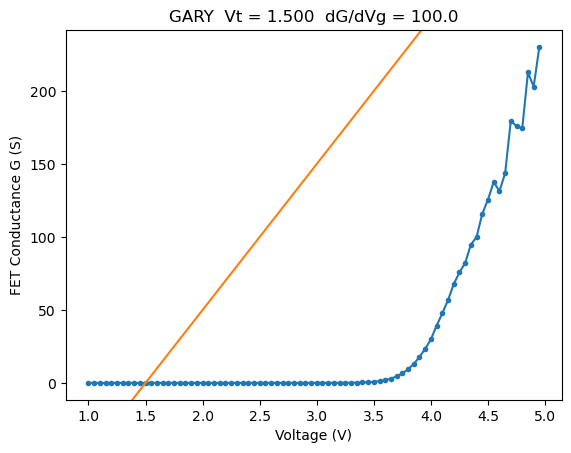

In [390]:
v = v2_amp
i = v1_amp - v2_amp
r = v/i
g = i/v
plt.plot(Vg_values, g, ".-")
plt.ylabel("FET Conductance G (S)")
plt.xlabel("Voltage (V)")
ylim = plt.ylim()

# Adjust these until the line goes through your data
Vt = 1.5
dG_dVg = 100
G_model = (Vg_values - Vt)*dG_dVg
plt.plot(Vg_values, G_model)
plt.ylim(ylim)
plt.title("GARY  Vt = %.3f  dG/dVg = %.1f" % (Vt,dG_dVg)) # Remove my name ;)

The model works quite well! (At least for me...). Note that it does not work great near depletion: near depletion, the model of constant mobility fails. There is not a "kink" where the conductance goes to zero right away, but instead a smoothed out tail. You can see this more clearly by looking at the conductance on a log scale:

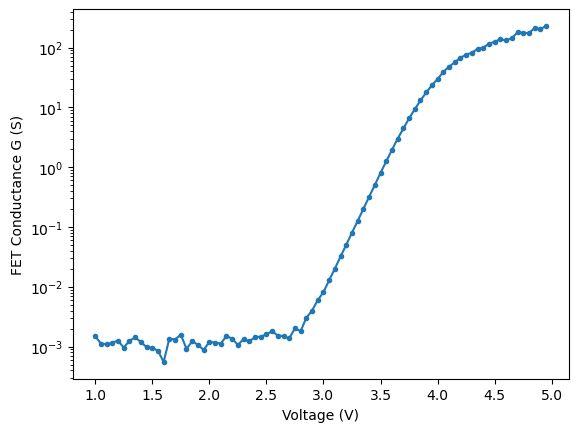

In [391]:
plt.plot(Vg_values, g, ".-")
plt.ylabel("FET Conductance G (S)")
plt.xlabel("Voltage (V)")
ylim = plt.ylim()
plt.yscale("log")

The smallest conductance Gary measured with this technique was around 1 mS (r = 1 kOHm). This is limited by the small value of the readout resistor we chose: it is hard to detect a MOhm resistance with a 100 ohm readout resistor because the voltage you will get for the Mohm channel resistance current is small. You can repeat this with a larger readout resistor: you will be able to measure higher channel resistances accurately (lower conductances) since the same current will give you more readout signal of the current, but then you will have difficulty in meauring small channel resistances since almost all the voltage drop will be across your resistor and you will suffer from noise in trying to measure the small drain voltage. 

## Level 2 work

Add your own code and code cells below for your level 2 work. 

In [ ]:
# Your level 2 code. Take screenshots for your logbook.